# End-to-End Customer Churn Prediction Pipeline using Scikit-learn

---

# Project Overview

This project implements a complete machine learning pipeline for predicting customer churn using the Telco Customer Churn Dataset.

The project demonstrates:

- automated preprocessing
- machine learning pipelines
- hyperparameter tuning
- model evaluation
- production-ready workflow design

The pipeline integrates preprocessing and model training into a reusable and scalable architecture using Scikit-learn Pipeline API.

---

# Objectives

The main objectives of this project are:

1. Build a reusable machine learning pipeline
2. Automate preprocessing steps
3. Train multiple machine learning models
4. Optimize model performance using GridSearchCV
5. Export the trained pipeline for deployment
6. Develop a production-oriented ML workflow

---

# Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Joblib
- Google Colab

---

# Dataset

The Telco Customer Churn dataset contains customer information such as:

- demographics
- services subscribed
- account information
- billing details
- churn status

The target variable predicts whether a customer is likely to leave the service.

# Problem Statement

Customer churn is one of the biggest challenges faced by subscription-based businesses.

Losing customers leads to:

- reduced revenue
- increased acquisition costs
- lower business growth

Machine learning can help organizations predict customers likely to churn so proactive retention strategies can be implemented.

This project develops a production-oriented machine learning pipeline capable of predicting customer churn using customer behavioral and demographic data.

In [2]:
!pip install -q scikit-learn
!pip install -q joblib

# Importing Required Libraries

The following libraries are used for:

- data preprocessing
- machine learning pipelines
- model training
- evaluation
- visualization
- model export

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

# Loading Dataset

The Telco Customer Churn dataset is loaded into a Pandas DataFrame for preprocessing and analysis.

In [4]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [5]:
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


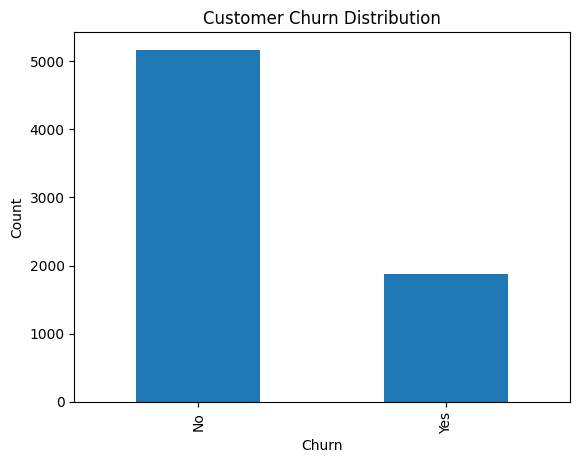

In [9]:
df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Count")

plt.show()

# Data Cleaning

The dataset is cleaned by:

- removing unnecessary columns
- handling incorrect datatypes
- converting target labels into numerical format

In [10]:
df.drop("customerID", axis=1, inplace=True)

In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [12]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [13]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [14]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing Pipeline

A ColumnTransformer pipeline is used to automate preprocessing separately for:

- numerical features
- categorical features

Advantages:

- reusable architecture
- cleaner code
- deployment readiness
- prevention of data leakage

In [16]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [17]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier", LogisticRegression(
            max_iter=1000
        ))
    ]
)

In [18]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier", RandomForestClassifier(
            random_state=42
        ))
    ]
)

In [19]:
logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [20]:
rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [21]:
logistic_preds = logistic_pipeline.predict(X_test)

rf_preds = rf_pipeline.predict(X_test)

In [22]:
print("Logistic Regression Accuracy:")

print(
    accuracy_score(
        y_test,
        logistic_preds
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        logistic_preds
    )
)

Logistic Regression Accuracy:
0.8055358410220014

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [23]:
print("Random Forest Accuracy:")

print(
    accuracy_score(
        y_test,
        rf_preds
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        rf_preds
    )
)

Random Forest Accuracy:
0.7778566359119943

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



In [24]:
cm = confusion_matrix(
    y_test,
    rf_preds
)

print(cm)

[[918 117]
 [196 178]]


# Hyperparameter Tuning using GridSearchCV

GridSearchCV is used to optimize model performance by searching for the best hyperparameter combinations.

In [25]:
param_grid = {
    "classifier__n_estimators": [100, 200],

    "classifier__max_depth": [5, 10, None]
}

grid_search = GridSearchCV(
    rf_pipeline,

    param_grid,

    cv=3,

    scoring="accuracy",

    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy')

In [26]:
print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'classifier__max_depth': 10, 'classifier__n_estimators': 100}


In [27]:
best_model = grid_search.best_estimator_

best_preds = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        best_preds
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [28]:
rf_model = best_model.named_steps["classifier"]

feature_importances = rf_model.feature_importances_

print(feature_importances[:10])

[0.01101861 0.13820512 0.08652694 0.12858266 0.01087906 0.01147106
 0.01015359 0.00985871 0.00898499 0.01086558]


# Exporting Pipeline

The complete machine learning pipeline is exported using Joblib.

This enables:

- model reuse
- deployment
- production integration

In [29]:
joblib.dump(
    best_model,
    "customer_churn_pipeline.pkl"
)

['customer_churn_pipeline.pkl']

In [30]:
loaded_pipeline = joblib.load(
    "customer_churn_pipeline.pkl"
)

print("Pipeline Loaded Successfully")

Pipeline Loaded Successfully


In [33]:
sample_customer = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(
    sample_customer
)

print("Predicted Churn:",prediction[0])

if prediction[0] == 1:
    print("The customer is likely to churn.")
else:
    print("The customer is likely to stay.")

Predicted Churn: 0
The customer is likely to stay.


# Results and Interpretation

The machine learning pipeline successfully automated:

- preprocessing
- encoding
- scaling
- model training
- prediction

Observations:

- Random Forest outperformed Logistic Regression
- Automated preprocessing improved workflow efficiency
- GridSearchCV enhanced model performance
- Pipeline architecture simplified deployment and reuse

The project demonstrates how production-ready ML workflows can be developed using Scikit-learn Pipeline API.

# Conclusion

This project successfully implemented an end-to-end machine learning pipeline for customer churn prediction.

The project demonstrated:

- preprocessing automation
- machine learning pipelines
- hyperparameter tuning
- reusable workflow design
- model export and deployment readiness

This architecture can serve as a foundation for enterprise machine learning systems and real-world predictive analytics applications.